In [1]:
import pandas as pd

df = pd.read_csv("../data/final/enhanced_model_data.csv")

for frac in [0.10, 0.25, 0.50, 0.75, 1.0]:
    subset = df.sample(frac=frac, random_state=42)
    subset.to_csv(f"../data/final/subset_{int(frac*100)}.csv", index=False)

print("Subset files created successfully.")

Subset files created successfully.


In [2]:
import pandas as pd
import math
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []

for pct in [10, 25, 50, 75, 100]:
    file_path = f"../data/final/subset_{pct}.csv"
    df = pd.read_csv(file_path)

    X = df.drop(columns=["task_duration_hours"])
    y = df["task_duration_hours"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(random_state=42)

    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()

    start_pred = time.time()
    predictions = model.predict(X_test)
    end_pred = time.time()

    mae = mean_absolute_error(y_test, predictions)
    rmse = math.sqrt(mean_squared_error(y_test, predictions))

    results.append({
        "dataset_percent": pct,
        "rows": len(df),
        "training_time_seconds": end_train - start_train,
        "prediction_time_seconds": end_pred - start_pred,
        "mae": mae,
        "rmse": rmse
    })

results_df = pd.DataFrame(results)
results_df.to_csv("../results/tables/scalability_results.csv", index=False)
results_df

,dataset_percent,rows,training_time_seconds,prediction_time_seconds,mae,rmse
0,10,2336,0.319279,0.006702,76.322138,187.808762
1,25,5840,0.810054,0.015607,67.845644,154.790374
2,50,11681,1.657251,0.032243,66.384704,150.580117
3,75,17522,2.472947,0.048078,58.229286,124.727497
4,100,23362,3.278686,0.067711,62.286163,167.917954


In [3]:
git add notebooks/03_scalability_testing.ipynb
git commit -m "Added scalability testing notebook"


SyntaxError: invalid decimal literal (3981826973.py, line 1)

In [4]:
import pandas as pd

df = pd.read_csv("../data/final/enhanced_model_data.csv")

for frac in [0.10, 0.25, 0.50, 0.75, 1.0]:
    subset = df.sample(frac=frac, random_state=42)
    subset.to_csv(f"../data/final/subset_{int(frac*100)}.csv", index=False)
    

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
scalability_df = pd.read_csv("../results/tables/scalability_results.csv")
scalability_df

,dataset_percent,rows,training_time_seconds,prediction_time_seconds,mae,rmse
0,10,2336,0.319279,0.006702,76.322138,187.808762
1,25,5840,0.810054,0.015607,67.845644,154.790374
2,50,11681,1.657251,0.032243,66.384704,150.580117
3,75,17522,2.472947,0.048078,58.229286,124.727497
4,100,23362,3.278686,0.067711,62.286163,167.917954


In [7]:
scalability_df.columns.tolist()


['dataset_percent',
 'rows',
 'training_time_seconds',
 'prediction_time_seconds',
 'mae',
 'rmse']

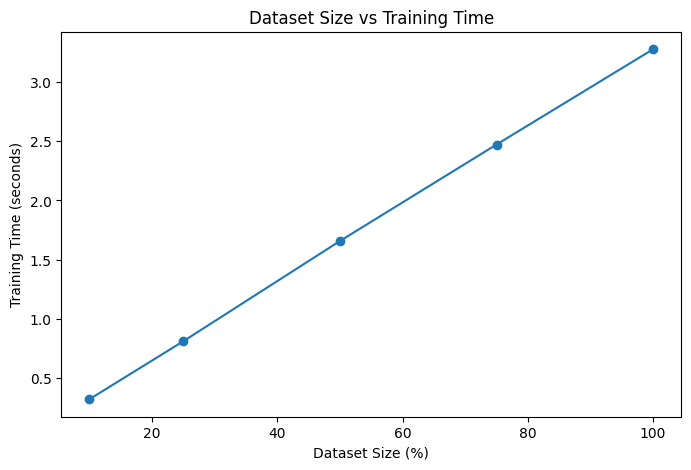

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(
    scalability_df["dataset_percent"],
    scalability_df["training_time_seconds"],
    marker="o"
)
plt.title("Dataset Size vs Training Time")
plt.xlabel("Dataset Size (%)")
plt.ylabel("Training Time (seconds)")
plt.savefig("../results/figures/scalability_training_time.png")
plt.show()

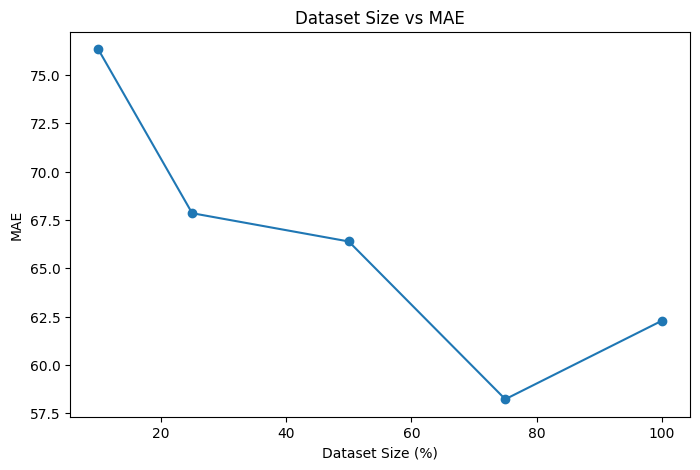

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(
    scalability_df["dataset_percent"],
    scalability_df["mae"],
    marker="o"
)
plt.title("Dataset Size vs MAE")
plt.xlabel("Dataset Size (%)")
plt.ylabel("MAE")
plt.savefig("../results/figures/scalability_mae.png")
plt.show()

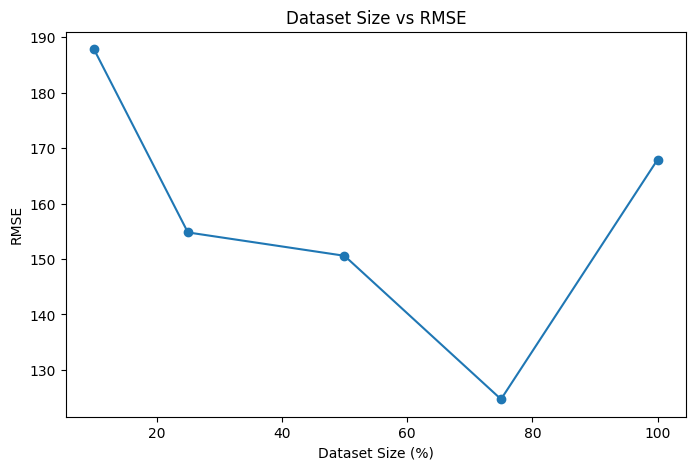

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(
    scalability_df["dataset_percent"],
    scalability_df["rmse"],
    marker="o"
)
plt.title("Dataset Size vs RMSE")
plt.xlabel("Dataset Size (%)")
plt.ylabel("RMSE")
plt.savefig("../results/figures/scalability_rmse.png")
plt.show()

In [11]:
ls results/figures

ls: results/figures: No such file or directory


## Scalability Interpretation

The scalability plots show how model performance and runtime change as dataset size increases.

- Training time increases as the dataset grows, which is expected for a larger training workload.
- MAE indicates how average prediction error changes with additional data.
- RMSE shows whether larger prediction errors become more or less significant as data volume increases.
- Together, these plots help evaluate whether the enhanced pipeline remains practical and stable at larger scales.

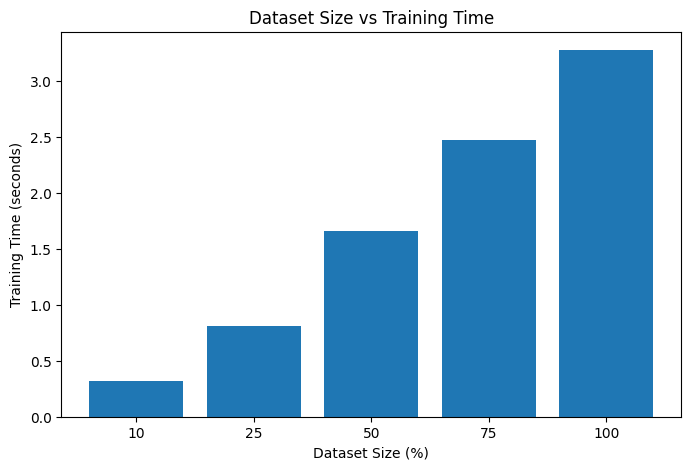

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(scalability_df["dataset_percent"].astype(str), scalability_df["training_time_seconds"])
plt.title("Dataset Size vs Training Time")
plt.xlabel("Dataset Size (%)")
plt.ylabel("Training Time (seconds)")
plt.savefig("../results/figures/scalability_training_time.png")
plt.show()

In [13]:
scalability_df.columns.tolist()

['dataset_percent',
 'rows',
 'training_time_seconds',
 'prediction_time_seconds',
 'mae',
 'rmse']

In [14]:
import pandas as pd
import matplotlib.pyplot as plt


In [15]:
scalability_df = pd.read_csv("../results/tables/scalability_results.csv")
scalability_df

,dataset_percent,rows,training_time_seconds,prediction_time_seconds,mae,rmse
0,10,2336,0.319279,0.006702,76.322138,187.808762
1,25,5840,0.810054,0.015607,67.845644,154.790374
2,50,11681,1.657251,0.032243,66.384704,150.580117
3,75,17522,2.472947,0.048078,58.229286,124.727497
4,100,23362,3.278686,0.067711,62.286163,167.917954


In [16]:
scalability_df.columns.tolist()

['dataset_percent',
 'rows',
 'training_time_seconds',
 'prediction_time_seconds',
 'mae',
 'rmse']

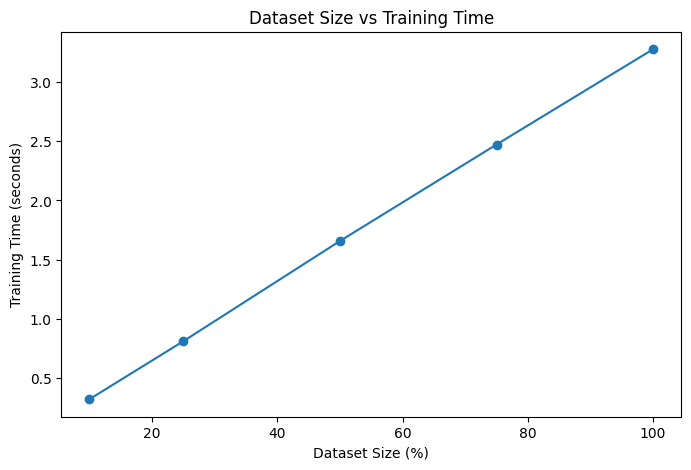

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    scalability_df["dataset_percent"],
    scalability_df["training_time_seconds"],
    marker="o"
)
plt.title("Dataset Size vs Training Time")
plt.xlabel("Dataset Size (%)")
plt.ylabel("Training Time (seconds)")
plt.savefig("../results/figures/scalability_training_time.png")
plt.show()

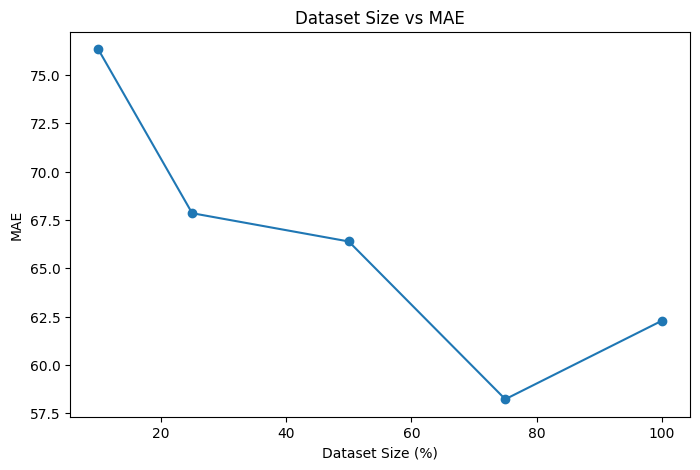

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(
    scalability_df["dataset_percent"],
    scalability_df["mae"],
    marker="o"
)
plt.title("Dataset Size vs MAE")
plt.xlabel("Dataset Size (%)")
plt.ylabel("MAE")
plt.savefig("../results/figures/scalability_mae.png")
plt.show()

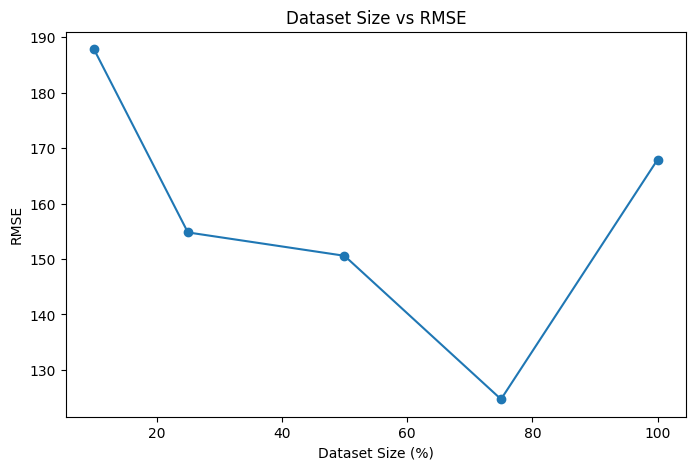

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(
    scalability_df["dataset_percent"],
    scalability_df["rmse"],
    marker="o"
)
plt.title("Dataset Size vs RMSE")
plt.xlabel("Dataset Size (%)")
plt.ylabel("RMSE")
plt.savefig("../results/figures/scalability_rmse.png")
plt.show()

## Scalability Interpretation

The scalability analysis shows that training time increases steadily as dataset size grows, indicating predictable computational scaling of the enhanced pipeline. Prediction time also rises gradually, but remains very low across all subset sizes.

In terms of predictive performance, MAE decreases from 76.32 at the 10% subset to 58.23 at the 75% subset, before rising slightly to 62.29 at 100%. RMSE follows the same pattern, improving from 187.81 at 10% to 124.73 at 75%, before increasing to 167.92 at 100%.

These results suggest that increasing dataset size generally improves predictive performance up to a point, but the full dataset introduces additional complexity, variability, or harder-to-predict cases. Overall, the enhanced pipeline scales well computationally and remains effective, although predictive performance is influenced by data complexity at full scale.